# Trajectory Probe: fPCA vs Scalar Features

Compares the **functional PCA** approach (Track A) against the scalar Mahalanobis
summary statistics used in the main analysis.

**Track A — fPCA on Mahalanobis sequence**
1. For each trace, compute the per-token Mahalanobis distance sequence `[T]`.
2. Resample to a fixed grid of length `target_len` (linear interpolation).
3. Flatten to `[target_len]` and stack traces → `[N, target_len]`.
4. Fit PCA on train-fold traces; project to `n_components` coefficients.
5. Use PC coefficients as features for a balanced logistic regression.

**Scalar baseline** — same PCA+Gaussian reference, but summary stats only:
mean, max, std, 90th-pct, mean/max at high-entropy tokens, entropy–Mahal correlation.

Results are loaded from DVC-tracked JSON outputs (run `dvc repro
trajectory_{model}_{dataset}` first).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

candidate_dirs = [Path.cwd(), Path.cwd() / "notebooks", *[p / "notebooks" for p in Path.cwd().parents]]
for candidate in candidate_dirs:
    if (candidate / "_viz_utils.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/_viz_utils.py")

import _viz_utils as vu

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

## Load results

In [2]:
ROOT = vu.results_root()

CONDITIONS = [
    ("qwen",     "math500"),
    ("qwen",     "gsm8k"),
    ("deepseek", "math500"),
    ("deepseek", "gsm8k"),
]


def load_scalar(model: str, dataset: str) -> dict:
    """Load the standard analyze.py results (scalar Mahalanobis features)."""
    return vu.load_result_json(model, dataset)


def load_trajectory(model: str, dataset: str) -> dict:
    """Load the trajectory probe results produced by dvc repro trajectory_{model}_{dataset}."""
    path = ROOT / model / f"{dataset}_trajectory" / f"{dataset}_trajectory_probe_results.json"
    return vu.load_json(path)


def get_scalar_row(scalar: dict, layer: int) -> dict:
    """Extract per-layer scalar metrics."""
    layer_data = scalar["layers"][str(layer)]
    return {
        "entropy":  scalar["entropy_baseline"]["roc_auc_mean"],
        "mahal":    layer_data["mahalanobis_only"]["roc_auc_mean"],
        "combined": layer_data["combined"]["roc_auc_mean"],
    }


def get_fpca_row(traj: dict, layer: int) -> dict:
    """Extract fpca_mahal AUC from trajectory probe results."""
    layer_data = traj["layer_results"][str(layer)]
    fpca = layer_data.get("fpca_mahal", {})
    return {
        "fpca_mahal_roc": fpca.get("roc_auc_mean"),
        "fpca_mahal_std": fpca.get("roc_auc_std"),
        "n_valid_folds":  fpca.get("n_valid_folds", 0),
    }


# Build comparison table
rows = []
for model, dataset in CONDITIONS:
    try:
        scalar = load_scalar(model, dataset)
        traj   = load_trajectory(model, dataset)
    except FileNotFoundError as exc:
        print(f"SKIP {model}/{dataset}: {exc}")
        continue

    layers = sorted(int(k) for k in traj["layer_results"])
    for layer in layers:
        sc = get_scalar_row(scalar, layer)
        fp = get_fpca_row(traj, layer)
        rows.append({
            "model": model, "dataset": dataset, "layer": layer,
            **sc, **fp,
            "delta_fpca_vs_mahal":    (fp["fpca_mahal_roc"] or float("nan")) - sc["mahal"],
            "delta_fpca_vs_combined": (fp["fpca_mahal_roc"] or float("nan")) - sc["combined"],
        })

print(f"Loaded {len(rows)} condition×layer rows")

Loaded 12 condition×layer rows


In [3]:
# Pretty-print summary table
print(f"{'model':>10} {'dataset':>8} {'L':>3}  {'entropy':>8} {'mahal':>8} {'combined':>10} {'fPCA-mahal':>12} {'Δ(fPCA-mah)':>13} {'Δ(fPCA-comb)':>14}")
print("-" * 100)
for r in rows:
    fpca = r["fpca_mahal_roc"]
    fpca_str = f"{fpca:.4f}" if fpca is not None else "    n/a"
    dm   = r["delta_fpca_vs_mahal"]
    dc   = r["delta_fpca_vs_combined"]
    print(
        f"{r['model']:>10} {r['dataset']:>8} {r['layer']:>3}  "
        f"{r['entropy']:>8.4f} {r['mahal']:>8.4f} {r['combined']:>10.4f} "
        f"{fpca_str:>12} {dm:>+13.4f} {dc:>+14.4f}"
    )

     model  dataset   L   entropy    mahal   combined   fPCA-mahal   Δ(fPCA-mah)   Δ(fPCA-comb)
----------------------------------------------------------------------------------------------------
      qwen  math500   7    0.7134   0.7420     0.7722       0.6192       -0.1228        -0.1530
      qwen  math500  14    0.7134   0.6783     0.7284       0.5928       -0.0856        -0.1357
      qwen  math500  21    0.7134   0.7190     0.7375       0.6945       -0.0245        -0.0430
      qwen    gsm8k   7    0.7600   0.6272     0.7752       0.5382       -0.0890        -0.2370
      qwen    gsm8k  14    0.7600   0.5952     0.7617       0.5255       -0.0697        -0.2362
      qwen    gsm8k  21    0.7600   0.6897     0.7812       0.5195       -0.1702        -0.2617
  deepseek  math500   7    0.7755   0.8261     0.8589       0.6561       -0.1700        -0.2028
  deepseek  math500  14    0.7755   0.7876     0.8084       0.6990       -0.0886        -0.1094
  deepseek  math500  21    0.7755  

## Visualisation

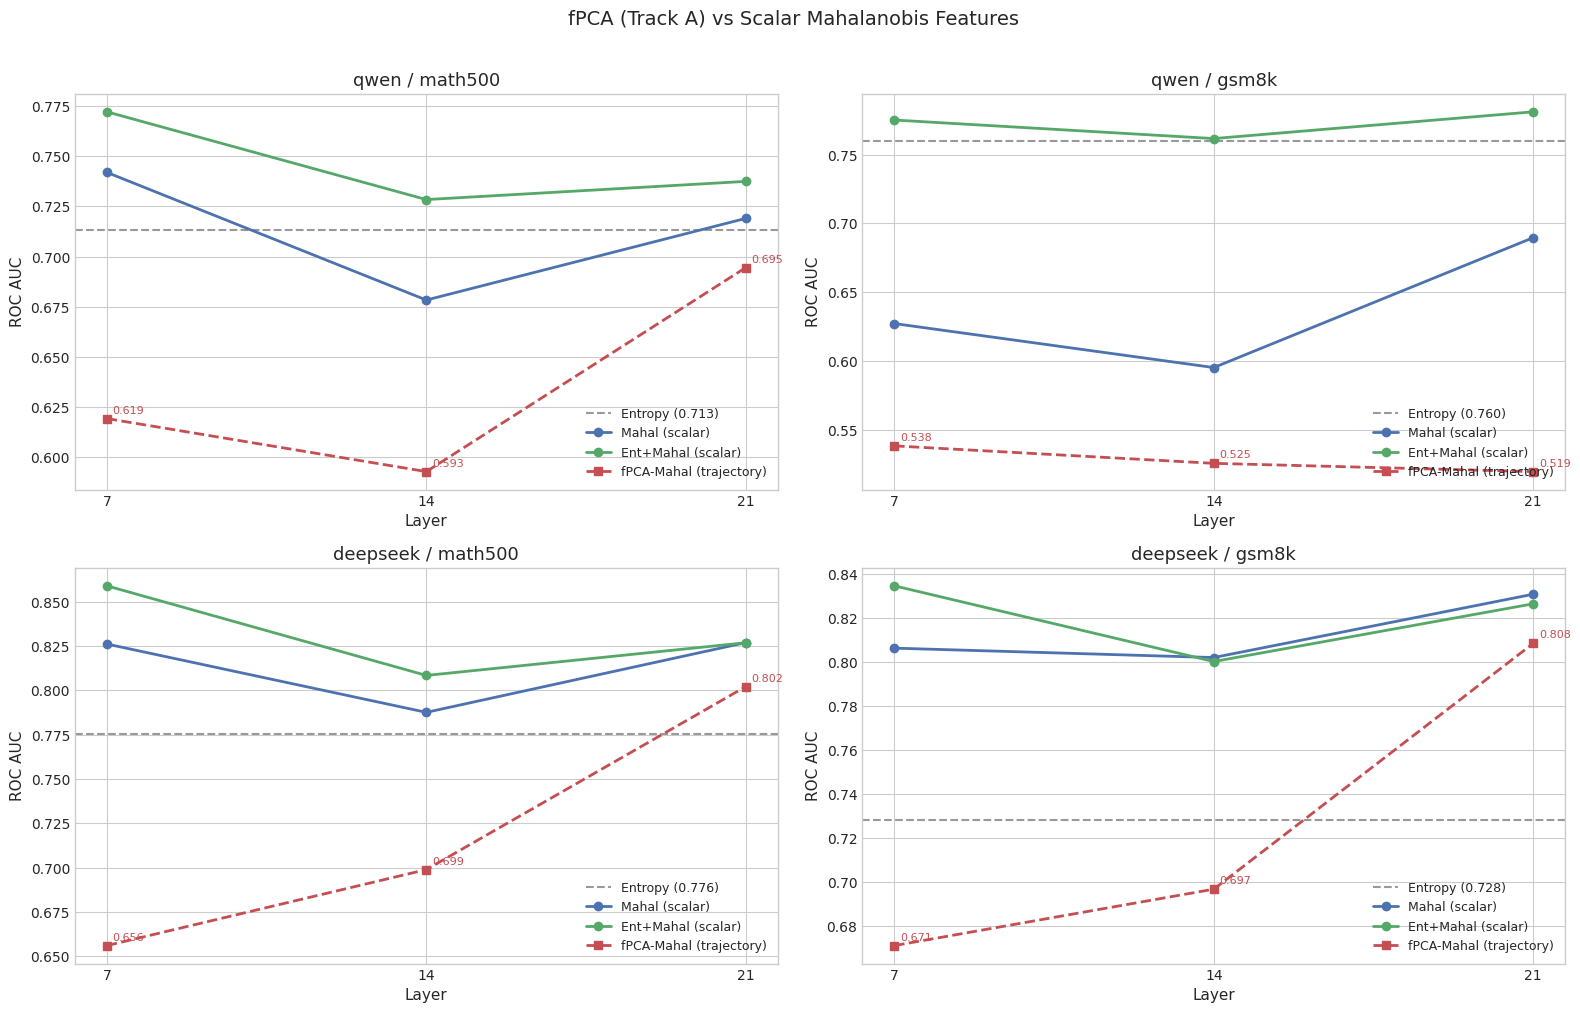

In [4]:
# Per-condition line plots: all methods across layers
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, (model, dataset) in zip(axes, CONDITIONS):
    cond_rows = [r for r in rows if r["model"] == model and r["dataset"] == dataset]
    if not cond_rows:
        ax.set_title(f"{model}/{dataset} — no data")
        ax.set_visible(False)
        continue

    cond_rows = sorted(cond_rows, key=lambda r: r["layer"])
    layers    = [r["layer"] for r in cond_rows]
    entropy   = cond_rows[0]["entropy"]  # same for all layers

    ax.axhline(entropy, linestyle="--", color="#999999", linewidth=1.5,
               label=f"Entropy ({entropy:.3f})")
    ax.plot(layers, [r["mahal"]    for r in cond_rows], marker="o", color="#4C72B0",
            linewidth=2, label="Mahal (scalar)")
    ax.plot(layers, [r["combined"] for r in cond_rows], marker="o", color="#55A868",
            linewidth=2, label="Ent+Mahal (scalar)")

    fpca_vals = [r["fpca_mahal_roc"] for r in cond_rows]
    if any(v is not None for v in fpca_vals):
        ax.plot(layers, fpca_vals, marker="s", color="#C44E52", linewidth=2,
                linestyle="--", label="fPCA-Mahal (trajectory)")
        # Annotate fPCA values
        for l, v in zip(layers, fpca_vals):
            if v is not None:
                ax.annotate(f"{v:.3f}", (l, v), xytext=(4, 4),
                            textcoords="offset points", fontsize=8, color="#C44E52")

    ax.set_title(f"{model} / {dataset}")
    ax.set_xlabel("Layer")
    ax.set_ylabel("ROC AUC")
    ax.set_xticks(layers)
    ax.legend(loc="lower right")

fig.suptitle("fPCA (Track A) vs Scalar Mahalanobis Features", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

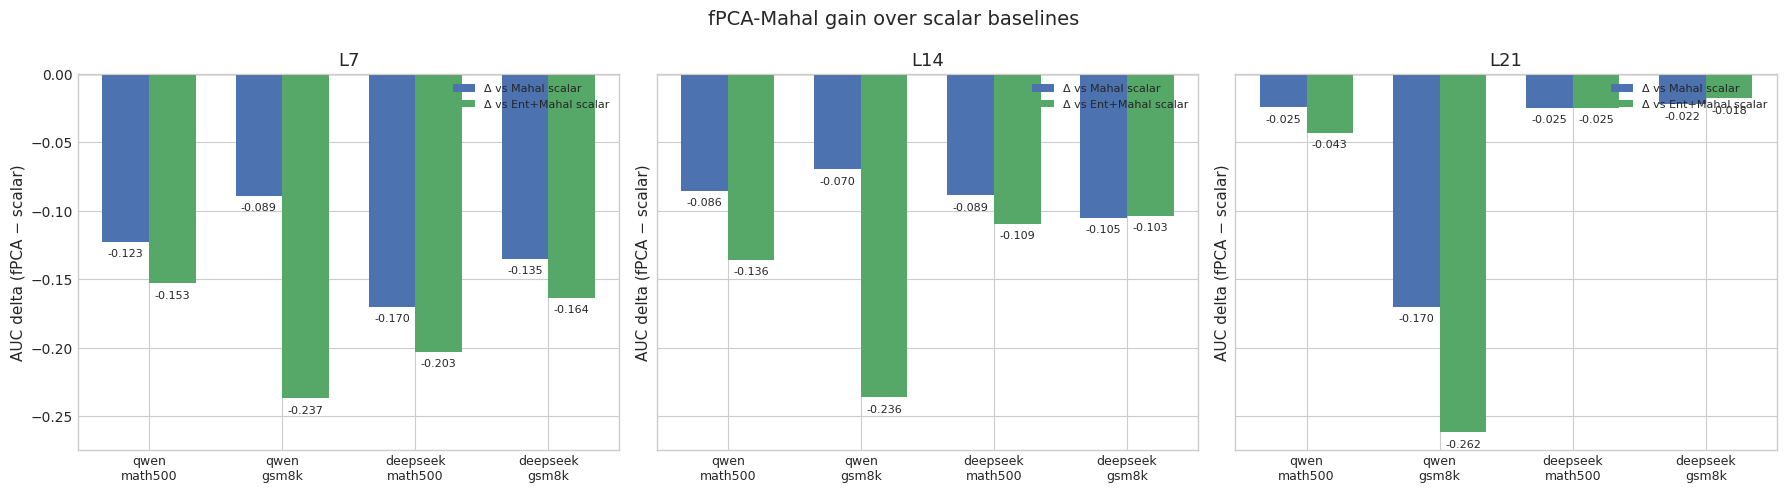

In [5]:
# Delta summary: fPCA vs scalar Mahal and vs scalar combined, per condition at each layer
if not rows:
    print("No data to plot.")
else:
    condition_labels = [f"{m}/{d}" for m, d in CONDITIONS
                        if any(r["model"] == m and r["dataset"] == d for r in rows)]
    unique_layers    = sorted({r["layer"] for r in rows})
    n_layers = len(unique_layers)
    width = 0.35

    fig, axes = plt.subplots(1, n_layers, figsize=(6 * n_layers, 5), sharey=True)
    if n_layers == 1:
        axes = [axes]

    for ax, layer in zip(axes, unique_layers):
        layer_rows = [r for r in rows if r["layer"] == layer]
        labels = [f"{r['model']}\n{r['dataset']}" for r in layer_rows]
        x = np.arange(len(labels))

        dm = np.array([r["delta_fpca_vs_mahal"]    for r in layer_rows])
        dc = np.array([r["delta_fpca_vs_combined"] for r in layer_rows])

        bars_m = ax.bar(x - width / 2, dm, width=width, color="#4C72B0",
                        label="Δ vs Mahal scalar")
        bars_c = ax.bar(x + width / 2, dc, width=width, color="#55A868",
                        label="Δ vs Ent+Mahal scalar")

        for bar in list(bars_m) + list(bars_c):
            v = bar.get_height()
            if np.isfinite(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        v + (0.002 if v >= 0 else -0.005),
                        f"{v:+.3f}", ha="center",
                        va="bottom" if v >= 0 else "top", fontsize=8)

        ax.axhline(0, color="black", linewidth=1, alpha=0.5)
        ax.set_title(f"L{layer}")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_ylabel("AUC delta (fPCA − scalar)")
        ax.legend(loc="upper right", fontsize=8)

    fig.suptitle("fPCA-Mahal gain over scalar baselines", fontsize=14)
    fig.tight_layout()
    plt.show()